# 0.33 — Does the genAI basket beat the market?

The basket from `0.30` is a list of companies whose 10-K/10-Q filings talk about the genAI
theme. This notebook asks the only question the desk cares about: **equal-weight the top 10
on the promotion date, hold, and do you beat the S&P 500?**

The short answer is *yes, and that yes is misleading*. The notebook is arranged so you can
see why: we look at **what put each company in the basket** before we look at what it
returned, because the returns only make sense once you have seen the scores.

### Rules of the test

| | |
|---|---|
| **theme** | genAI, promoted `2023-01-17` (notebook `0.29`) |
| **entry** | first trading day on/after the information date — no look-ahead |
| **weights** | equal, buy and hold, no rebalancing, no costs |
| **benchmark** | `SPY`, adjusted closes (dividends reinvested on *both* sides; the bare `^GSPC` price index would flatter us by ~1.5%/yr) |
| **prices** | Yahoo split/dividend-adjusted closes, cached per ticker in `data/raw/prices/` |

### Two biases, both flattering the basket

1. **Survivorship in the universe.** The ticker file is *today's* universe resolved through
   *today's* SEC ticker map (`0.31`). A company that delisted between 2023 and now is not in
   the file at all, so it can never enter the basket or drag it down.
2. **Ticker reuse.** A ticker that changed hands returns the new company's price history.

Read every number below as an optimistic estimate.

In [1]:
import sys; sys.path.insert(0, "..")
import matplotlib.pyplot as plt
import pandas as pd

import theme_backtest as bt

plt.rcParams.update({"font.size": 11, "axes.spines.top": False, "axes.spines.right": False})
BLUE, YELLOW, AQUA, RED, GRAY = "#2a78d6", "#eda100", "#1baf7a", "#d62728", "#8a8a8a"
PROC = "../data/processed"

# the genAI vocab, split into what it is actually made of
CORE   = ["chatgpt", "chatgpt-like", "chatgpt-style", "openai"]   # the theme itself
GIANTS = ["nvidia", "google", "microsoft", "alibaba", "baidu", "netease", "jpmorgan"]
OTHER  = ["altman", "ernie"]
VOCAB  = CORE + GIANTS + OTHER

# a company mentioning its *own* name in its own filing tells us nothing about the theme
SELF = {"NVDA": "nvidia", "GOOG": "google", "GOOGL": "google", "MSFT": "microsoft",
        "BABA": "alibaba", "BIDU": "baidu", "NTES": "netease", "JPM": "jpmorgan"}

T0, T120 = "2023-01-17", "2023-05-17"   # promotion date, and one reporting season later

In [2]:
pit = pd.read_parquet(f"{PROC}/theme_basket_genai_pit.parquet")
b120 = pd.read_parquet(f"{PROC}/theme_basket_genai.parquet")

top10 = pit.head(10)["ticker"].tolist()
direct = b120[(b120.chatgpt > 0) | (b120.openai > 0)]["ticker"].tolist()

px = bt.load_prices(sorted(set(pit.ticker) | set(b120.ticker) | {"SPY"}))
print(f"prices: {px.shape[1]} tickers, {px.index.min().date()} -> {px.index.max().date()}")
print(f"PIT top-10 (entry {T0}) : {top10}")
print(f"direct mentioners, {len(direct)} names (entry {T120}) : {direct}")

prices: 125 tickers, 1973-02-21 -> 2026-07-27
PIT top-10 (entry 2023-01-17) : ['NVDA', 'TRIP', 'GOOG', 'EA', 'MYPS', 'APPS', 'EXPE', 'EBAY', 'CRNC', 'FFAI']
direct mentioners, 13 names (entry 2023-05-17) : ['VUZI', 'INOD', 'VERI', 'STGW', 'RXRX', 'OKLO', 'LPSN', 'SKIL', 'MSFT', 'SSTK', 'NIXX', 'NRDY', 'MPWR']


## 1. What actually put these ten companies in the basket?

Before any performance number, here is the diagnostic that explains all of them. For each
top-10 name: the terms that generated its score, how many of those mentions are the company
**naming itself**, and how many are **core genAI terms** (`chatgpt*`, `openai`).

In [3]:
def drivers(row, k=3):
    hits = sorted(((t, int(row[t])) for t in VOCAB if row[t] > 0), key=lambda x: -x[1])
    return ", ".join(f"{t} x{n}" for t, n in hits[:k])

rows = []
for _, r in pit.head(10).iterrows():
    own = SELF.get(r.ticker)
    rows.append({"ticker": r.ticker,
                 "company": r.company.title()[:26],
                 "score drivers (top 3 terms)": drivers(r),
                 "core genAI mentions": int(r[CORE].sum()),
                 "self-mentions": f"{r[own] / r.total:.0%}" if own else "—",
                 "total mentions": int(r.total)})
why = pd.DataFrame(rows).set_index("ticker")
why

,company,score drivers (top 3 terms),core genAI mentions,self-mentions,total mentions
ticker,,,,,
NVDA,Nvidia Corp,"nvidia x600, microsoft x10, google x1",0,98%,613
TRIP,"Tripadvisor, Inc.","google x15, jpmorgan x4, alibaba x2",0,—,24
GOOG,Alphabet Inc.,"google x262, microsoft x5, alibaba x1",0,97%,269
EA,Electronic Arts Inc.,"microsoft x29, google x8, netease x1",0,—,39
MYPS,"Playstudios, Inc.","google x90, jpmorgan x21, netease x10",0,—,129
APPS,"Digital Turbine, Inc.","google x24, microsoft x3, baidu x3",0,—,32
EXPE,"Expedia Group, Inc.","google x13, jpmorgan x2, altman x2",0,—,18
EBAY,Ebay Inc,"google x6, alibaba x2, jpmorgan x2",0,—,11
CRNC,Cerence Inc.,"google x1, microsoft x1, alibaba x1",0,—,4


In [4]:
print(f"core genAI mentions across the whole top-10 : {int(pit.head(10)[CORE].to_numpy().sum())}")

core_named = pit[pit[CORE].sum(axis=1) > 0]
print(f"companies in the full {len(pit)}-name basket with any core genAI term : {len(core_named)}")
core_named.assign(rank=core_named.index + 1)[["rank", "ticker", "company"] + CORE + ["altman"]]

core genAI mentions across the whole top-10 : 0
companies in the full 100-name basket with any core genAI term : 1


,rank,ticker,company,chatgpt,chatgpt-like,chatgpt-style,openai,altman
37,38,OKLO,Oklo Inc.,0,0,0,8,53


**This is the finding the rest of the notebook is just pricing.**

Not one of the top 10 mentions ChatGPT or OpenAI — not once. The basket is ranked entirely
by mentions of the *giants* in the vocab, and those mentions mean completely different
things depending on who is writing:

- **NVDA (98% self) and GOOG (97% self)** rank first and third because their own 10-Ks
  repeat their own names. The vocab contains `nvidia` and `google` because the *news* was
  about NVIDIA and Google — so these two companies select themselves. This is a
  **self-mention artifact**, not a measurement of exposure.
- **TRIP, MYPS, APPS, EBAY, EXPE** rank on `google` (15, 90, 24, 6, 13 mentions) — that is
  Google Play, Google Ads, distribution and competition risk. **EA** ranks on `microsoft`
  x29, meaning Xbox. These are **platform dependencies**, the opposite of a genAI bet.
- **CRNC** scrapes in on four single mentions and **FFAI** on seven, which is noise.

So the honest description of this portfolio is: *one chip company, one search company, and
eight companies that mention big tech in their risk factors.*

**And it is not just the top 10.** In the entire 100-name point-in-time basket, exactly
**one** company mentions a core genAI term — `OKLO`, ranked 38th, a nuclear fission startup.
It says `openai` eight times because it came public through Sam Altman's SPAC (AltC) and his
biography sits in the filing. The only OpenAI mention the filing channel offers on promotion
day is a sponsor bio in a reactor company's paperwork. That is the `altman`/Oklo entity
collision from the failure-modes slide, and it is also the cleanest possible illustration of
why the news channel — not filings — has to seed the day-one basket (`0.30`).

## 2. The scoreboard

Three portfolios, **each entered on the date its own information actually existed** — so
every row below is something you could physically have traded, none of them are hindsight:

- **PIT top-10**, entered `2023-01-17`. What the pipeline hands you on promotion day.
- **+120d top-10**, entered `2023-05-17`. The same scorer once FY2022 10-Ks have landed.
  This is **not** a look-ahead portfolio and it is not an alternative to the PIT basket —
  it is the *"wait one reporting season for confirmation"* strategy that `0.30` and the deck
  explicitly recommend, and the point of including it is to find out whether waiting
  actually fixes anything. (It does not: see the 12-month column.)
- **direct mentioners**, entered `2023-05-17`. The 13 companies that literally write
  `chatgpt`/`openai` — the purest expression of the theme, and the most interesting control.

Plus the diagnostic portfolios that isolate the concentration. First, the check that the two
`+120d` portfolios really are clean:

In [5]:
# Every filing that fed a basket must pre-date that basket's entry, or the test is rigged.
for name, entry in [("genai_pit", T0), ("genai", T120)]:
    f = pd.read_parquet(f"{PROC}/theme_basket_{name}_filings.parquet")
    last = pd.to_datetime(f["file_date"]).max()
    ok = last < pd.Timestamp(entry)
    print(f"{name:10s} entry {entry} | last filing used {last.date()} | "
          f"{'OK, no look-ahead' if ok else 'LOOK-AHEAD'} ({(pd.Timestamp(entry) - last).days}d margin)")

genai_pit  entry 2023-01-17 | last filing used 2023-01-10 | OK, no look-ahead (7d margin)
genai      entry 2023-05-17 | last filing used 2023-05-15 | OK, no look-ahead (2d margin)


In [6]:
PORTFOLIOS = [("PIT top-10",           top10,                                       T0),
              ("PIT top-10 ex-NVDA",   [t for t in top10 if t != "NVDA"],           T0),
              ("PIT top-10 ex NVDA,GOOG", [t for t in top10 if t not in ("NVDA", "GOOG")], T0),
              ("PIT all 100 names",    pit["ticker"].tolist(),                      T0),
              ("+120d top-10",         b120.head(10)["ticker"].tolist(),            T120),
              ("direct mentioners",    direct,                                      T120),
              ("SPY (benchmark)",      ["SPY"],                                     T0)]

rows = []
for label, tk, start in PORTFOLIOS:
    curve, held, _ = bt.equal_weight_curve(px, tk, start)
    spy, _, _ = bt.equal_weight_curve(px, ["SPY"], start)
    s = bt.summarise(curve)
    w = px.loc[start:, held].ffill()
    per_name = w.iloc[-1] / w.iloc[0] - 1
    rows.append({"portfolio": label, "n": len(held), "entry": start,
                 "total return": s["total_return"],
                 "SPY over same window": spy.iloc[-1] - 1,
                 "excess": s["total_return"] - (spy.iloc[-1] - 1),
                 "ann. vol": s["ann_vol"], "max drawdown": s["max_drawdown"],
                 "return/vol": s["ann_return"] / s["ann_vol"],
                 "names beating SPY": f"{int((per_name > spy.iloc[-1] - 1).sum())}/{len(held)}"})

board = pd.DataFrame(rows).set_index("portfolio")
board.style.format({"total return": "{:.1%}", "SPY over same window": "{:.1%}",
                    "excess": "{:+.1%}", "ann. vol": "{:.1%}",
                    "max drawdown": "{:.1%}", "return/vol": "{:.2f}"}) \
     .background_gradient(subset=["excess"], cmap="RdYlGn", vmin=-0.6, vmax=0.6)

,n,entry,total return,SPY over same window,excess,ann. vol,max drawdown,return/vol,names beating SPY
portfolio,,,,,,,,,
PIT top-10,10,2023-01-17,133.5%,94.3%,+39.2%,29.1%,-30.0%,0.94,4/10
PIT top-10 ex-NVDA,9,2023-01-17,35.8%,94.3%,-58.5%,25.0%,-42.7%,0.36,3/9
"PIT top-10 ex NVDA,GOOG",8,2023-01-17,8.1%,94.3%,-86.2%,28.1%,-52.9%,0.08,2/8
PIT all 100 names,99,2023-01-17,152.6%,94.3%,+58.2%,31.5%,-32.8%,0.95,37/99
+120d top-10,10,2023-05-17,160.4%,85.4%,+74.9%,38.5%,-35.1%,0.91,5/10
direct mentioners,13,2023-05-17,48.5%,85.4%,-36.9%,54.9%,-58.3%,0.24,3/13
SPY (benchmark),1,2023-01-17,94.3%,94.3%,+0.0%,15.1%,-18.8%,1.38,0/1


**How to read this.** `excess` is the headline anyone will quote. `names beating SPY` and
`return/vol` are the two columns that tell you whether the headline means anything.

The PIT top-10 beats SPY by ~39pp — and only **4 of its 10 names** beat SPY, it carries
**twice the index's volatility**, and its return-per-unit-of-vol is *below* SPY's. A
portfolio that outperforms while most of its holdings underperform is a portfolio with one
position in it.

## 3. The headline portfolio over time

Same PIT top-10, measured at each horizon rather than end-to-end. `hit rate` = the share of
the basket's own names that beat SPY over that particular horizon.

In [7]:
FINE = [1, 2, 3, 6, 9, 12, 18, 24, 36]

h = bt.horizon_table(px, top10, T0, horizons=FINE)
h = h.rename(columns={"basket": "PIT top-10", "hit_rate": "hit rate"})
h.drop(columns="n").style.format({"PIT top-10": "{:.1%}", "SPY": "{:.1%}",
                                  "excess": "{:+.1%}", "hit rate": "{:.0%}"}) \
 .background_gradient(subset=["excess"], cmap="RdYlGn", vmin=-0.5, vmax=0.5)

,PIT top-10,SPY,excess,hit rate
horizon,,,,
1m,5.0%,2.4%,+2.6%,50%
2m,-2.6%,-1.6%,-1.0%,30%
3m,-1.3%,4.5%,-5.8%,30%
6m,17.2%,14.2%,+3.0%,30%
9m,-4.2%,10.8%,-15.0%,20%
12m,7.2%,20.5%,-13.3%,30%
18m,39.5%,43.0%,-3.5%,20%
24m,61.8%,54.5%,+7.3%,30%
36m,122.2%,80.9%,+41.3%,40%


The excess column is negative or negligible everywhere in the **first 12 months** and the
win arrives late, in years 2 and 3, as NVIDIA compounds — section 5.1 plots this. The hit
rate peaks at 50% in the first month and then sits at **30% for the next two years**. The
basket was never broadly right; it was narrowly right, eventually.

## 4. Where the return came from

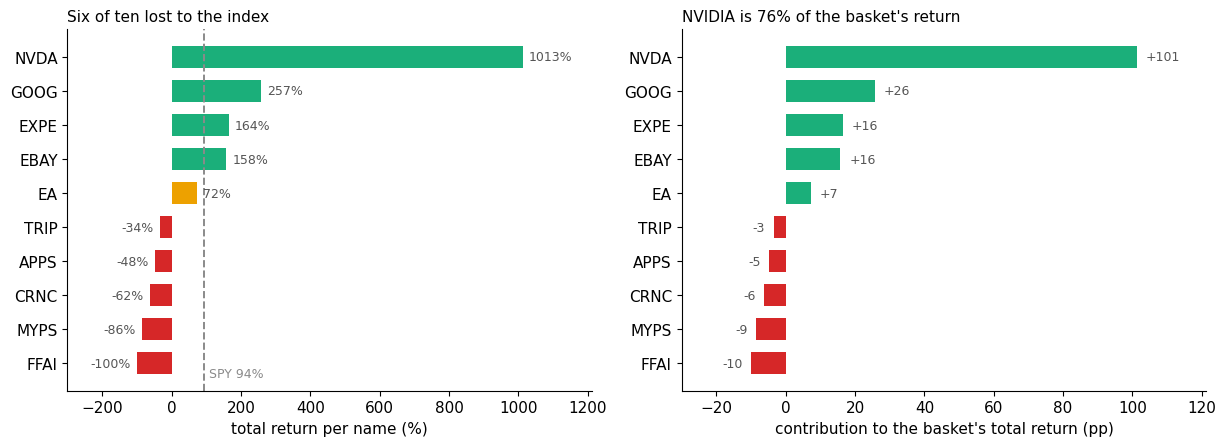

basket total return 133.5pp = NVDA 101pp + everything else 32pp   (SPY 94pp)


In [8]:
w = px.loc[T0:, top10 + ["SPY"]].ffill()
rets = (w.iloc[-1] / w.iloc[0] - 1)
spy_ret = rets.pop("SPY")
rets = rets.sort_values()
contrib = 100 * rets / len(top10)          # equal weight -> each name contributes r_i / N

fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.6))

ax = axes[0]
colors = [AQUA if v > spy_ret else (YELLOW if v > 0 else RED) for v in rets.values]
ax.barh(rets.index, 100 * rets.values, color=colors, height=0.66)
ax.axvline(100 * spy_ret, color=GRAY, lw=1.4, ls="--")
ax.text(100 * spy_ret + 15, -0.4, f"SPY {spy_ret:.0%}", fontsize=9, color=GRAY)
for y, v in enumerate(rets.values):
    ax.text(100 * v + (18 if v >= 0 else -18), y, f"{v:.0%}", va="center",
            ha="left" if v >= 0 else "right", fontsize=9, color="#555")
ax.set_xlabel("total return per name (%)")
ax.set_title("Six of ten lost to the index", fontsize=11, loc="left")
ax.margins(x=0.18)

ax = axes[1]
ax.barh(contrib.index, contrib.values, color=[AQUA if v > 0 else RED for v in contrib.values],
        height=0.66)
ax.set_xlabel("contribution to the basket's total return (pp)")
ax.set_title(f"NVIDIA is {contrib.max() / contrib.sum():.0%} of the basket's return",
             fontsize=11, loc="left")
for y, v in enumerate(contrib.values):
    ax.text(v + (2.5 if v >= 0 else -2.5), y, f"{v:+.0f}", va="center",
            ha="left" if v >= 0 else "right", fontsize=9, color="#555")
ax.margins(x=0.18)

fig.tight_layout(); plt.show()
print(f"basket total return {contrib.sum():.1f}pp = NVDA {contrib['NVDA']:.0f}pp "
      f"+ everything else {contrib.drop('NVDA').sum():.0f}pp   (SPY {100 * spy_ret:.0f}pp)")

NVIDIA alone supplies about three-quarters of the basket's return. The other nine names
together produce less than SPY did. `FFAI` went to **-99.9%** — a total loss the equal
weighting quietly absorbed because one position was up tenfold.

Note what this means together with section 1: the basket's entire result rests on the one
name that got in through the self-mention artifact. The scorer was right about NVIDIA for
the wrong reason, in a year when the entity dominating the news also dominated the P&L.
There is no mechanism here that makes that repeat.

## 5. Equity curves

### 5.1 The short horizons, up close

The 3.5-year chart in 5.2 is dominated by NVIDIA compounding in years 2–3 and hides the
window a desk would actually have judged this on. Same portfolios, four zoom levels.

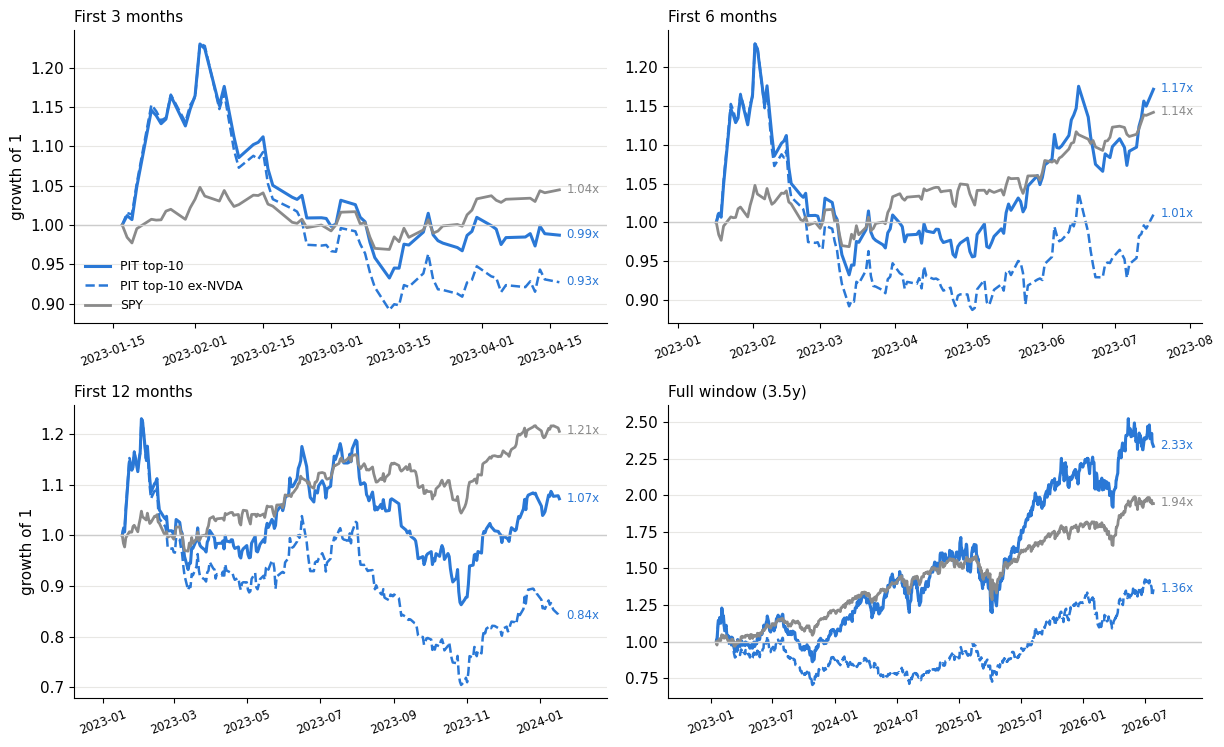

In [9]:
ZOOMS = [(3, "First 3 months"), (6, "First 6 months"),
         (12, "First 12 months"), (None, "Full window (3.5y)")]
LINES = [("PIT top-10", top10, BLUE, "-", 2.2),
         ("PIT top-10 ex-NVDA", [t for t in top10 if t != "NVDA"], BLUE, "--", 1.8),
         ("SPY", ["SPY"], GRAY, "-", 2.0)]

fig, axes = plt.subplots(2, 2, figsize=(12.4, 7.6))
for ax, (months, title) in zip(axes.ravel(), ZOOMS):
    stop = None if months is None else pd.Timestamp(T0) + pd.DateOffset(months=months)
    for label, tk, color, ls, lw in LINES:
        curve, _, _ = bt.equal_weight_curve(px, tk, T0, end=stop)
        ax.plot(curve.index, curve.values, color=color, ls=ls, lw=lw, label=label)
        ax.annotate(f"{curve.iloc[-1]:.2f}x", (curve.index[-1], curve.iloc[-1]),
                    textcoords="offset points", xytext=(5, -2), fontsize=8.5, color=color)
    ax.axhline(1, color="#ccc", lw=1)
    ax.set_title(title, fontsize=11, loc="left")
    ax.grid(axis="y", color="#e8e7e4", lw=0.8); ax.set_axisbelow(True)
    ax.margins(x=0.11)
    ax.tick_params(axis="x", labelsize=8.5, rotation=20)
axes[0, 0].legend(fontsize=9, frameon=False, loc="lower left")
axes[0, 0].set_ylabel("growth of 1"); axes[1, 0].set_ylabel("growth of 1")
fig.tight_layout(); plt.show()

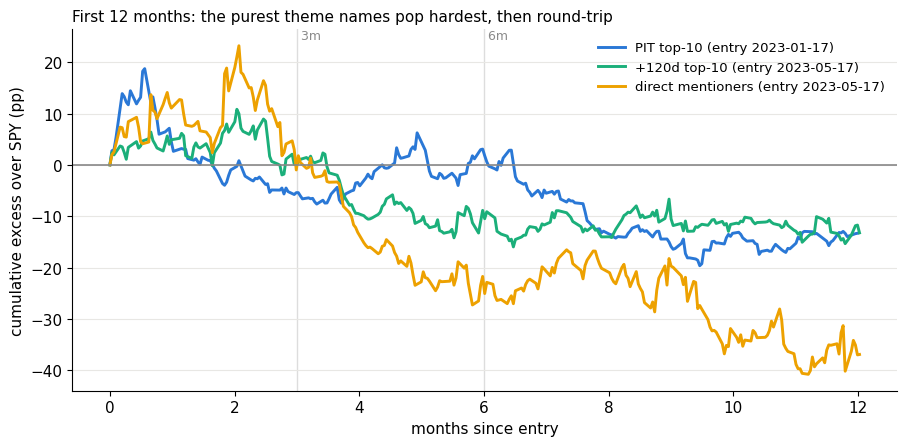

In [10]:
fig, ax = plt.subplots(figsize=(9.2, 4.6))
for label, tk, start, color in [("PIT top-10", top10, T0, BLUE),
                                ("+120d top-10", b120.head(10)["ticker"].tolist(), T120, AQUA),
                                ("direct mentioners", direct, T120, YELLOW)]:
    e = bt.excess_curve(px, tk, start, months=12)
    ax.plot(e.index, 100 * e.values, color=color, lw=2.1, label=f"{label} (entry {start})")
ax.axhline(0, color="#888", lw=1.2)
for m in (3, 6):
    ax.axvline(m, color="#ddd", lw=1, zorder=0)
    ax.text(m, ax.get_ylim()[1], f" {m}m", fontsize=9, color=GRAY, va="top")
ax.set_xlabel("months since entry")
ax.set_ylabel("cumulative excess over SPY (pp)")
ax.set_title("First 12 months: the purest theme names pop hardest, then round-trip",
             fontsize=11, loc="left")
ax.legend(fontsize=9.5, frameon=False)
ax.grid(axis="y", color="#e8e7e4", lw=0.8); ax.set_axisbelow(True)
fig.tight_layout(); plt.show()

Plotting excess against *months since entry* rather than calendar dates lets the two
portfolios entered at `+120d` sit on the same axis as the point-in-time one.

All three trace the same shape — an early pop, gone by month 3, and **every version of the
basket behind the index at 12 months** (-13pp, -13pp, -37pp).

The direct mentioners are the extreme case, and the most revealing one. The portfolio that
most looks like a genAI bet leads by **+19pp at two months**, is level by three, **-23pp by
six** and **-37pp by twelve**. That round trip is a hype cycle in micro-caps, not exposure
to a technology.

At **3 months** nothing is distinguishable from noise (-5.8pp, +0.5pp, +1.8pp). At
**6 months** only the point-in-time basket is ahead, by 3pp, and that is already NVIDIA
carrying it rather than the basket working.

So there is **no edge at a 3–6 month horizon**. The +39pp headline is a two-to-three-year
single-stock story that a desk running quarterly reviews would have killed long before it
paid — the basket is 15pp behind the index at month 9.

### 5.2 The full window

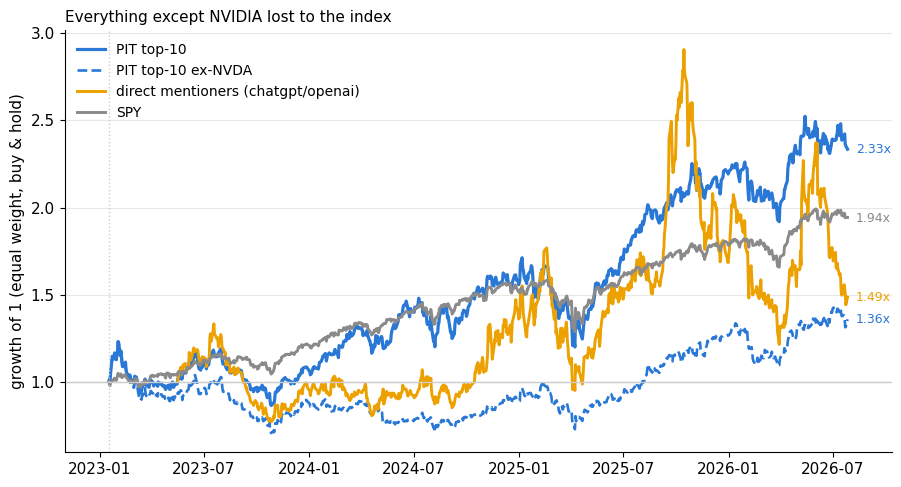

In [11]:
fig, ax = plt.subplots(figsize=(9.2, 5.0))
for label, tk, start, color, ls, lw in [
        ("PIT top-10", top10, T0, BLUE, "-", 2.3),
        ("PIT top-10 ex-NVDA", [t for t in top10 if t != "NVDA"], T0, BLUE, "--", 1.9),
        ("direct mentioners (chatgpt/openai)", direct, T120, YELLOW, "-", 2.1),
        ("SPY", ["SPY"], T0, GRAY, "-", 2.1)]:
    curve, _, _ = bt.equal_weight_curve(px, tk, start)
    ax.plot(curve.index, curve.values, color=color, ls=ls, lw=lw, label=label)
    ax.annotate(f"{curve.iloc[-1]:.2f}x", (curve.index[-1], curve.iloc[-1]),
                textcoords="offset points", xytext=(6, -3), fontsize=9, color=color)
ax.axhline(1, color="#ccc", lw=1)
ax.axvline(pd.Timestamp(T0), color="#ccc", lw=1, ls=":")
ax.set_ylabel("growth of 1 (equal weight, buy & hold)")
ax.set_title("Everything except NVIDIA lost to the index", fontsize=11, loc="left")
ax.legend(fontsize=10, frameon=False, loc="upper left")
ax.grid(axis="y", color="#e8e7e4", lw=0.8); ax.set_axisbelow(True)
ax.margins(x=0.06)
fig.tight_layout(); plt.show()

## 6. The control: what happened to the *pure* theme signal?

The 13 companies that actually wrote `chatgpt` or `openai` in a filing are the closest thing
this pipeline produces to a clean genAI signal. If term-counting measures thematic exposure,
this is the portfolio that should work.

In [12]:
w = px.loc[T120:, [t for t in direct if t in px.columns] + ["SPY"]].ffill()
r = (w.iloc[-1] / w.iloc[0] - 1).sort_values(ascending=False)
pd.DataFrame({"total return since " + T120: r,
              "vs SPY": r - r["SPY"]}).style.format("{:+.1%}") \
  .background_gradient(subset=["vs SPY"], cmap="RdYlGn", vmin=-1.5, vmax=1.5)

,total return since 2023-05-17,vs SPY
INOD,+616.6%,+531.2%
OKLO,+299.0%,+213.5%
MPWR,+230.1%,+144.6%
SPY,+85.4%,+0.0%
STGW,+35.1%,-50.3%
MSFT,+26.8%,-58.6%
RXRX,-44.1%,-129.5%
VUZI,-44.5%,-129.9%
VERI,-72.5%,-158.0%
NRDY,-75.2%,-160.6%


**The purest signal is the worst portfolio** — roughly 37pp behind SPY, with 3 of 13 names
beating the index. Look at the composition: `NIXX`, `SKIL`, `NRDY`, `STGW`, `SSTK` are
micro-caps for which writing "ChatGPT" in a 10-K was the cheapest available way to be an AI
company. `MSFT` and `MPWR` — the two names with real genAI revenue — are in there, weighted
identically to the press releases.

This is the `mention ≠ exposure` failure mode from the deck, now with a number on it. Early
mention correlates with **promotional incentive**, not with revenue. Counting the word
harder would have made this portfolio worse, not better.

## 7. Takeaways

1. **The genAI top-10 beat SPY (+133% vs +94% over 3.5y) and it is not a good result.**
   Median name +19%, only 4 of 10 beat the index, half lost money outright, three lost more
   than half their value and `FFAI` went to zero (-99.9%). Ex-NVIDIA
   the basket returns +36% with a **-43% drawdown against SPY's -19%**. At ~2x the index's
   volatility, it loses on a risk-adjusted basis *even with NVIDIA in it*.

2. **There is no edge at a 3–6 month horizon.** Every version of the basket — point-in-time,
   `+120d`, and direct mentioners — is behind SPY at 12 months (-13pp, -13pp, -37pp), and at
   3 months the differences are noise. The headline is a years-2-and-3 effect; on the review
   cycle a desk actually runs, this component would have been shut down before it paid.
   Note especially that the `+120d` basket — the "wait a reporting season for the filings to
   confirm the theme" step that `0.30` and the deck recommend — lands in the *same place* as
   the point-in-time one. Waiting buys a more accurate **description** of the theme; it does
   not buy performance.

3. **No company in the top 10 mentions ChatGPT or OpenAI even once** — and in the whole
   100-name basket exactly one does, a nuclear startup carrying Sam Altman's SPAC bio. The
   ranking is driven by giant-name mentions, which are self-mentions for NVDA/GOOG (98%/97%
   of their score) and platform-dependency risk factors for everyone else. The portfolio was
   never a genAI portfolio.

4. **The one name that carried it got in through the artifact.** NVIDIA is ~75% of the
   return and ranks first because its own filing says "NVIDIA" 600 times.

5. **The purest theme signal performed worst** (-37pp vs SPY). Mention tracks promotional
   incentive, not exposure — the strongest single argument in this notebook against using
   raw term counts as weights.

6. **All of this is optimistic**, since delisted companies cannot enter the universe.

### What this implies for v2

Term counting on filings is a usable **candidate generator** — it surfaced Veritone,
Innodata and Vuzix early — but a term count is not a portfolio weight. In rough order of
expected impact:

- **drop self-mentions and giant names from scoring** (kills the artifact that produced both
  the top rank and the whole return);
- **require co-occurrence with a core theme term to enter** the basket at all (would have
  emptied this top-10 and forced the news channel to fill it, which `0.30` already argues is
  where the t0 signal lives);
- **weight by exposure, not mentions** — segment revenue, capex, or an LLM-scored read of
  *how* the term is used (supplier vs. customer vs. risk factor);
- **cap single-name weight**, so the result is not one position wearing a basket's clothing.

### Reproduce

```python
import theme_backtest as bt
px = bt.load_prices(["NVDA", "GOOG", "SPY"])          # cached under data/raw/prices/
bt.horizon_table(px, bt.basket_tickers("genai_pit", 10), "2023-01-17")
```